In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import phik


In [2]:
df = pd.read_csv("../data/diamonds.csv")

In [3]:
df.head(10)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [4]:
df = df.drop(columns = 'Unnamed: 0')

Удалили лишний столбец


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [6]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [7]:
df.duplicated().sum()

np.int64(146)

In [8]:
df = df.drop_duplicates()

Удалим дубли


In [9]:
numeric = df.select_dtypes(include='number').columns.tolist()

In [10]:
numeric

['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

In [11]:
category = df.select_dtypes(include='object').columns.tolist()

/var/folders/jt/pfrf2kqn59d1ph0418pyq4mr0000gn/T/ipykernel_46920/2110772613.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category = df.select_dtypes(include='object').columns.tolist()


In [12]:
category

['cut', 'color', 'clarity']

Разделили на категориальные и количественные признаки

In [13]:
def plot_boxplots(dataframe, num_columns):
    num_plots = len(num_columns)
    num_cols = min(2, num_plots) 
    num_rows = (num_plots + 1) // num_cols  
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6*num_rows))  

    for i, column in enumerate(num_columns):
        row = i // num_cols  
        col = i % num_cols  

        ax = axes[row, col] if num_rows > 1 else axes[col]
        dataframe.boxplot(column=column, ax=ax)  
        ax.set_title(f"Боксплот для столбца {column}")  
        ax.set_xlabel("Столбец") 
        ax.set_ylabel("Значение")  

    plt.tight_layout()  
    plt.show()

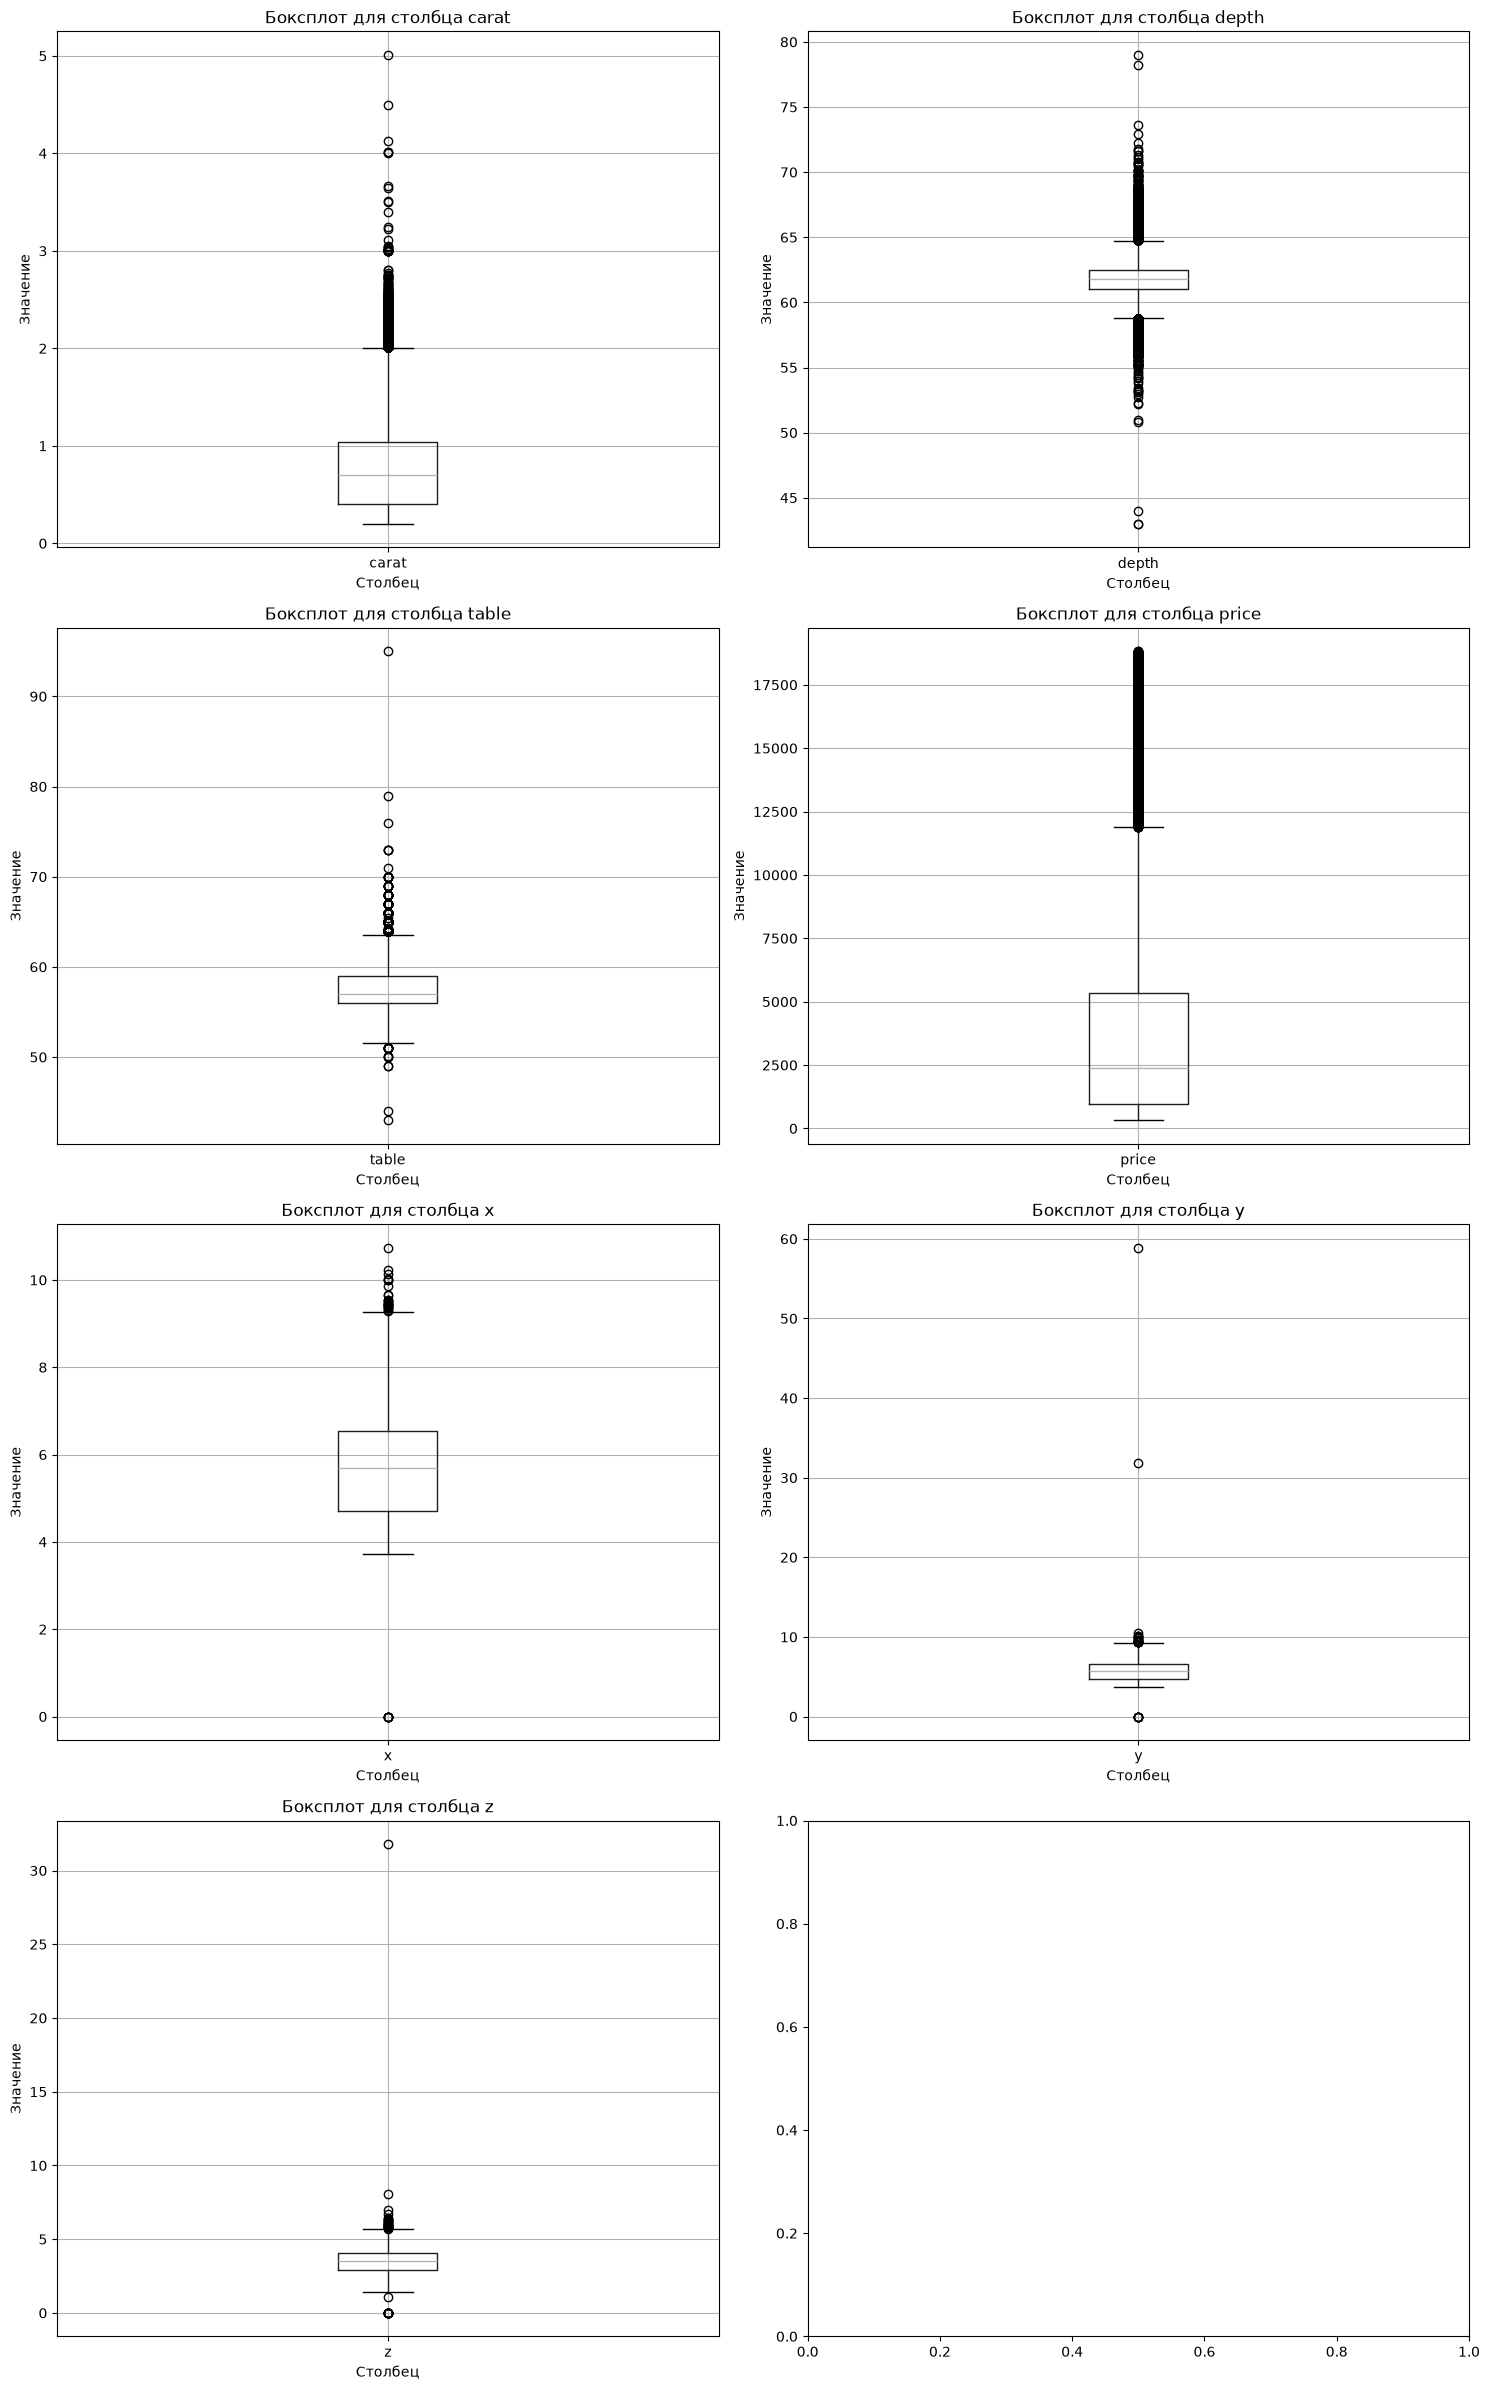

In [14]:
plot_boxplots(df, numeric)

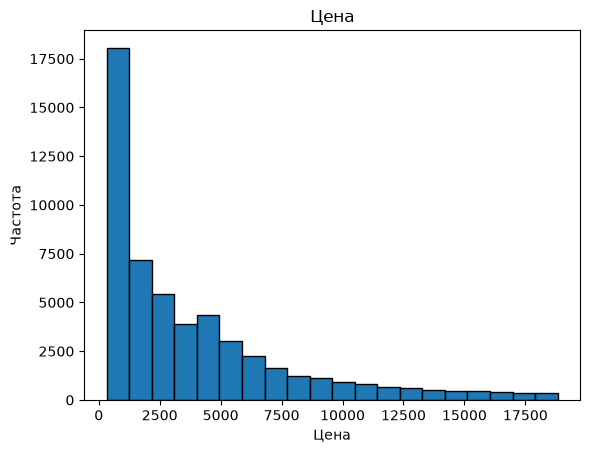

In [15]:
plt.hist(df['price'], bins=20, edgecolor='black')
plt.title('Цена')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()

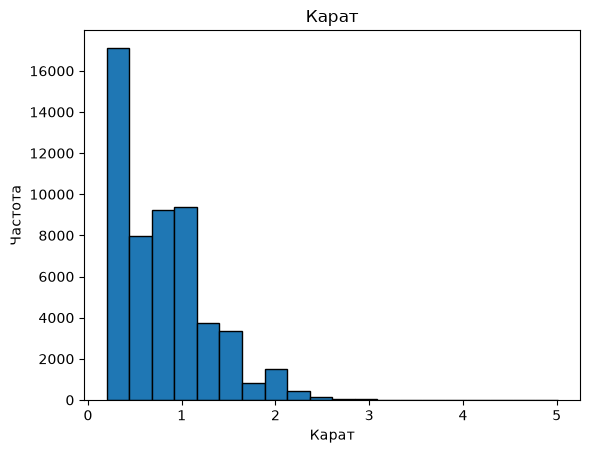

In [16]:
plt.hist(df['carat'], bins=20, edgecolor='black')
plt.title('Карат')
plt.xlabel('Карат')
plt.ylabel('Частота')
plt.show()

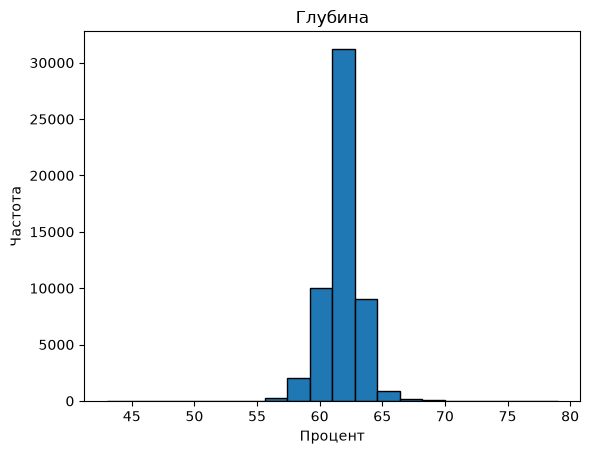

In [17]:
plt.hist(df['depth'], bins=20, edgecolor='black')
plt.title('Глубина')
plt.xlabel('Процент')
plt.ylabel('Частота')
plt.show()

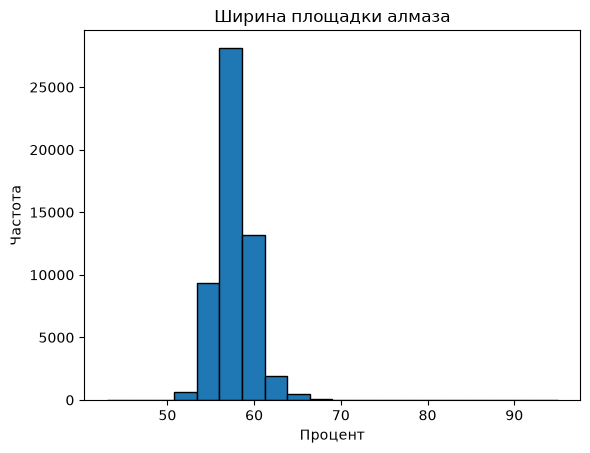

In [18]:
plt.hist(df['table'], bins=20, edgecolor='black')
plt.title('Ширина площадки алмаза')
plt.xlabel('Процент')
plt.ylabel('Частота')
plt.show()

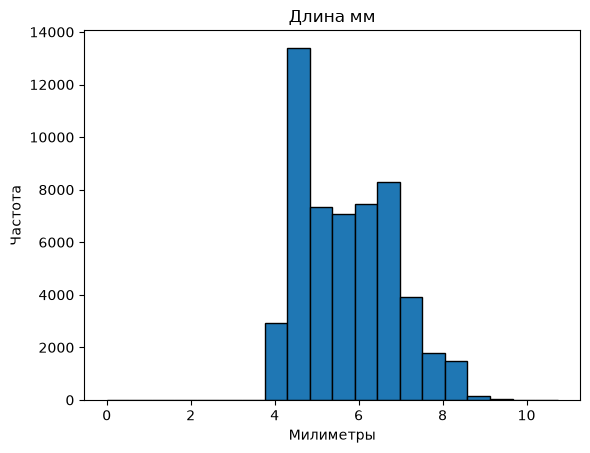

In [19]:
plt.hist(df['x'], bins=20, edgecolor='black')
plt.title('Длина мм')
plt.xlabel('Милиметры')
plt.ylabel('Частота')
plt.show()

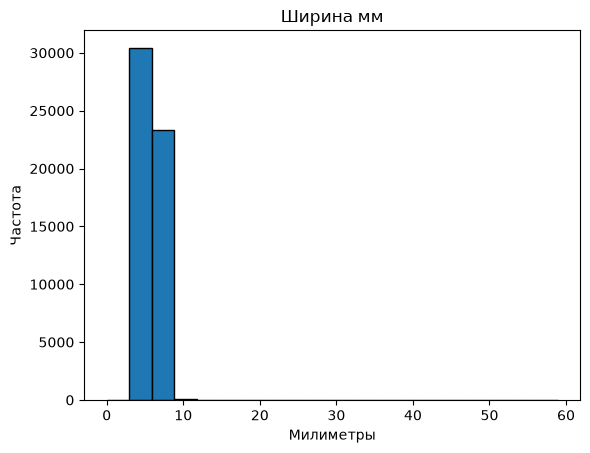

In [20]:
plt.hist(df['y'], bins=20, edgecolor='black')
plt.title('Ширина мм')
plt.xlabel('Милиметры')
plt.ylabel('Частота')
plt.show()

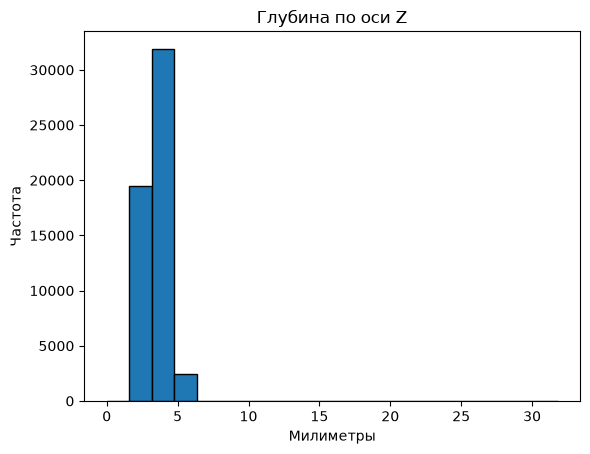

In [21]:
plt.hist(df['z'], bins=20, edgecolor='black')
plt.title('Глубина по оси Z')
plt.xlabel('Милиметры')
plt.ylabel('Частота')
plt.show()

 В столбцах x, y, z обнаружены аномальные значения. Рассчитаем прецентиль

In [22]:
df[['x', 'y', 'z']].quantile([0.01, 0.05, 0.95, 0.99]).T

,0.01,0.05,0.95,0.99
x,4.02,4.29,7.66,8.35
y,4.04,4.30,7.64,8.33
z,2.48,2.65,4.73,5.15


In [23]:
df['x']

0        3.95
1        3.89
2        4.05
3        4.20
4        4.34
         ... 
53935    5.75
53936    5.69
53937    5.66
53938    6.15
53939    5.83
Name: x, Length: 53794, dtype: float64

In [ ]:
x_precentile_99 = df['x'].quantile(0.99)
y_precentile_99 = df['y'].quantile(0.99)
z_precentile_99 = df['z'].quantile(0.99)
x_precentile_01 = df['x'].quantile(0.01)
y_precentile_01 = df['y'].quantile(0.01)
z_precentile_01 = df['z'].quantile(0.01)
df = df[df['x']<= x_precentile_99]
df = df[df['y']<= y_precentile_99]
df = df[df['z']<= z_precentile_99]
df = df[df['x']>= x_precentile_01]
df = df[df['y']>= y_precentile_01]
df = df[df['z']>= z_precentile_01]

In [38]:
x_precentile_01 = df['x'].quantile(0.01)
y_precentile_01 = df['y'].quantile(0.01)
z_precentile_01 = df['z'].quantile(0.01)

In [40]:
df = df[df['x']<= x_precentile_99]
df = df[df['y']<= y_precentile_99]
df = df[df['z']<= z_precentile_99]
df = df[df['x']>= x_precentile_01]
df = df[df['y']>= y_precentile_01]
df = df[df['z']>= z_precentile_01]

In [33]:
def unique_columns(columns, data):
    for column in columns:
        unique_values = set(data[column])
        print(f'уникальные значения в {column}: {unique_values}')


In [34]:
unique_columns(category, df)

уникальные значения в cut: {'Ideal', 'Premium', 'Fair', 'Very Good', 'Good'}
уникальные значения в color: {'J', 'H', 'G', 'I', 'F', 'E', 'D'}
уникальные значения в clarity: {'IF', 'SI2', 'VVS1', 'SI1', 'VVS2', 'VS1', 'VS2', 'I1'}


In [35]:
def create_pie_charts(data, columns, color='default'):
    for column in columns:
        counts = data[column].value_counts()

        df = pd.DataFrame({column: counts.index, 'count': counts.values})

        fig = px.pie(df, values='count', names=column, title=f'Круговая диаграмма для {column}')
        fig.show()

In [36]:
create_pie_charts(df, category)

Большинство бриллиантов считаются идеальными 39.9% Далее идут премиальные 25.6% и очень хорошие 22.4%

 "Цвет бриллианта, где D — лучший, а J — худший." D 12.7%, a J 5.21%, но больше всего бриллиантов в цвете G 20.9%

 "Чистота — показатель степени прозрачности алмаза (I1 (худший), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (лучший))" Большинство SI1 24.2%, VS2 22.7%. Самый лучший IF всего 3.32%

In [37]:

phik_corr = df.phik_matrix()

fig = px.imshow(
    phik_corr,
    text_auto=True,
    aspect='auto',
    color_continuous_scale='Peach'
)

fig.update_layout(
    title='PHIK-корреляция признаков',
    width=900,
    height=700
)

fig.show()

interval columns not set, guessing: ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']


Цена очень сильно коррелирует с каратом (весом алмаза), x, y, z (Длины граней алмаза). Самая низкая корреляция с глубиной и цветом.